In [1]:
import sys

from pathlib import Path
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
sys.path.append('../')
sys.path.append('../src')

from src.foldingAlg import load_Final

Final_list, Final_toplot, Final_labels, Final_palette = load_Final()

In [180]:
upperDf = pd.read_csv('../result/neutral_path/upper_with_rnafold.csv', sep='\t', names=['Algorithm', 'target', 'trial', 'final', 'distance', 'Total moves', 'Total tries', 'Hamming'])
upperDf

,Algorithm,target,trial,final,distance,Total moves,Total tries,Hamming
0,Basic cofold,CAUCUGCUGUGAGGGAAUGCCCAUGACUAUGAAGCAAGUUAUACUA...,UCACCCCAGGCCCACGACGCCCUCAGGCGGCAGUUUAAGCUACGGC...,CUACUUCAGUGCGGGAAUGCCCAUGGGUACGCUGCAAGUUAUAGUA...,25,168,7889,70
1,Basic cofold,CAUCUGCUGUGAGGGAAUGCCCAUGACUAUGAAGCAAGUUAUACUA...,AUCCCCUGUUAUUGCAUAGAACGUACUAGCAAGAAUUCCUCGGUCC...,CAUCUACGGGUAGGUAAUGCACAUGACUAUGAAGAAAAUGCCACUA...,27,153,5600,69
2,Basic cofold,CAUCUGCUGUGAGGGAAUGCCCAUGACUAUGAAGCAAGUUAUACUA...,AAUGCCUUGCCUAUACAGACGACGUAUCUAUCAGCAUCUGCUGAGA...,CAUCUCCUGAGCGGUAAUGCCCAUGCCUAUGAAGAAAGUUCUUCUA...,19,126,4774,68
3,Basic cofold,CAUCUGCUGUGAGGGAAUGCCCAUGACUAUGAAGCAAGUUAUACUA...,UCAGAUAUCCAGGGAUGCGGGCAAACUUAACACAACUGAGAAGCUG...,CAUCUGCUGAGAGGGGAUCCCCAUAACUAUGAAGCCUGGUAAGCUC...,21,96,3959,60
4,Basic cofold,CAUCUGCUGUGAGGGAAUGCCCAUGACUAUGAAGCAAGUUAUACUA...,CGGAGGACAGAUAAAACCGGGUAUCCCACCGCGAAUUAAGAAGCAA...,CAGCCGCAAUGAGAGAACGCCCUUUACUAUCACGGAAAUUAUACUA...,23,129,3995,73
...,...,...,...,...,...,...,...,...
29995,RNAfold,ACAUAGCUUAGAGCCCUCCUACCAGGGCCUGGCAUUCAAUCUAUGA...,UGUUUAUCUUCGGUAUGAGCCGCCCAACAGGACGGGUGUUCAUCUU...,ACAUAGCUUAGACCCCGGUUAGCAGUACCUGGCCUGCAAUCGGUGU...,26,144,4139,76
29996,RNAfold,ACAUAGCUUAGAGCCCUCCUACCAGGGCCUGGCAUUCAAUCUAUGA...,GCCACCAUAAAUGACCGGGCGUUUACGUUUAAAUCUGUCUCCCAAG...,ACGAUGGUUAGAGUCAACCUACUAGGGCCUGUCAUUCAAUCUAUGU...,21,121,5554,71
29997,RNAfold,ACAUAGCUUAGAGCCCUCCUACCAGGGCCUGGCAUUCAAUCUAUGA...,UCGUAACUGUUACUUAACAUGCCCCUCAAACACUAAGAUUAGCUUA...,ACAUAGCUCAAAUCCCCCCUACCCCGGCAUGCCAUUCAAUCCGAGU...,21,120,5869,69
29998,RNAfold,ACAUAGCUUAGAGCCCUCCUACCAGGGCCUGGCAUUCAAUCUAUGA...,UCCCGCUCGGCGGGAGUUGUGAGAUCAGGAUGGGUGUUGAGACCAG...,ACUUCUCUUAGAGGUAUCCUGCGAGGGCCUGGCAUUCGUUAUAUGA...,25,87,2273,75


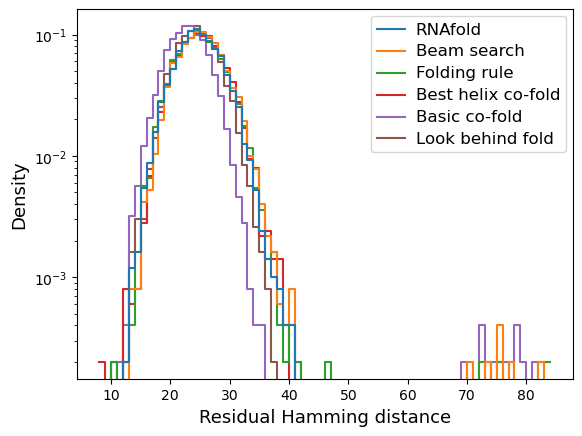

In [182]:
# df = upperDf[upperDf['label'].isin(Final_toplot)]
# g = sns.displot(data=df, x='path', hue='label', kind="hist", hue_order=toplot, element="poly", fill=False)
g = sns.histplot(data=upperDf, x='distance', hue='Algorithm', hue_order=Final_toplot[:], 
                 binwidth=1, stat="density", common_norm=False,
                 element="step", fill=False,
                )
legend = g.get_legend()
legend.set_title("")
for t, l in zip(legend.texts, Final_labels[:]):
    t.set_text(l)
    t.set_fontsize(12)
plt.yscale('log')
plt.ylabel('Density', fontsize=13)
plt.xlabel('Residual Hamming distance', fontsize=13)
# sns.move_legend(g, "upper left", bbox_to_anchor=(.55, .6))
plt.savefig('fig/upper_with_rnafold.pdf', dpi=200, bbox_inches='tight')

# Toward "True" structure of RNAfold 

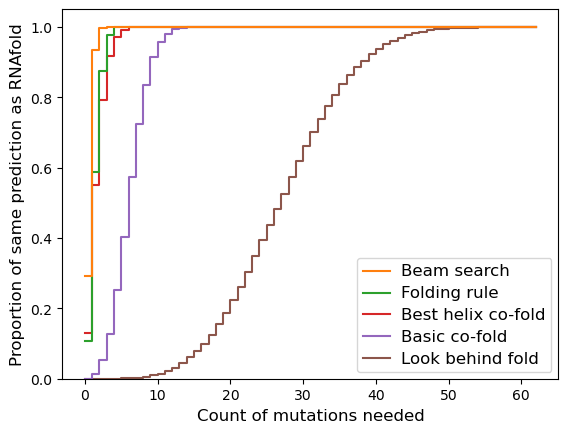

In [184]:
toRNAfoldDf = pd.read_csv('../result/neutral_path/all_to_RNAfold_bp.csv', sep='\t', names=['Algorithm', 'trial', 'final', 'distance', 'Total moves', 'Hamming'])

# plt.subplots(figsize=(15, 5))

g = sns.histplot(
    data=toRNAfoldDf[toRNAfoldDf['distance']==0], x="Hamming", hue="Algorithm", binwidth=1,
    element="step", fill=False, cumulative=True, stat="density", common_norm=False,
    hue_order=Final_toplot[1:],
    palette=Final_palette,
    # stat="density", common_norm=False,
)

legend = g.get_legend()
legend.set_title("")
for t, l in zip(legend.texts, Final_labels[1:]):
    t.set_text(l)
    t.set_fontsize(12)
plt.ylabel('Proportion of same prediction as RNAfold', fontsize=12)
plt.xlabel('Count of mutations needed', fontsize=12)
plt.savefig('fig/aroundRNAfold_bp.pdf', dpi=200, bbox_inches='tight')

# Maximum Neutral Path

In [167]:
maxpathDf = pd.read_csv('../result/neutral_path/max_path_with_rnafold.csv', sep='\t')
maxpathDf

,Algorithm,trial,final,distance,Total moves,Hamming
0,Basic cofold,GUCCACGACUAGUAUUUGAUUAGUCCACCAUCACUCUCCUGGUCUC...,AGAAGAAUAGUUACCCCCUAGCUAUACAGCCGCGAACUUCCCGGGU...,0,145,100
1,Basic cofold,GUGCGUUCGAGAAGCAGAACGUCUGGGAGACCUAAGAGCGCUCUGU...,UCUUCCCUAGCGUUUGAGGGAGUAUACGCGGUAGUUGCUCUCGAAG...,0,128,100
2,Basic cofold,AGGCAACCCAACAAGUGUGACAACCAGUACACUUGUACACGGCUUU...,GUUAUUUAGGGAGUCCCGUGGCGUAGAGCGGGACUCGGGACUGCCC...,0,150,100
3,Basic cofold,GGGUUAGGACUCUGGAUACUGGAACGAUUAACCCAGUCCCGGAAAG...,UUUGCGUACGGAGCACACUGCUCGUUGGCGUAGGUAGGAAACGCGC...,0,106,100
4,Basic cofold,GGCAUGAAUAUUGCUCUCGCGGCCUUCAUCGGCGUAGGACUUUCGA...,CAGUCUGUCCGACUAAGAUGCUUAGGAGCGCUGCCCACCUCAAGCG...,0,139,100
...,...,...,...,...,...,...
59995,Look behind fold,GACUGCAAUGUCGGCCUGAGGCCAGUCUUAUGACGUUCGACCAGAA...,CCUGUAUUAAGGACAUAAGAUGUACGUAACCACGCCGUAGAUGACG...,1,174,99
59996,Look behind fold,CCGAUCUCACCCUAAGAUUAAUCAGAGUAGCAACUCACCAGGUCAG...,GACGGUCGUAGAAGGACCGCUAACUCAGUCAUCUGAUAACGAGAUA...,5,142,95
59997,Look behind fold,AUCUUAAUUCCGAGAGGCGUAUCCCACGCCGCCCCCAGCUUUCCGC...,UCGCGUCCAUUCGCGUCGCACAAUAUGCGAUAAUUUUCGAACUACG...,0,111,100
59998,Look behind fold,GGGCAACGCCCGCAUGAGAAACCUCACGCCAUAAAUGCAUAGGCGA...,CUCUUCAAGAGAUUGUGAUUUUUCACUCGGCCUUCAUUUCCCCGAC...,0,209,100


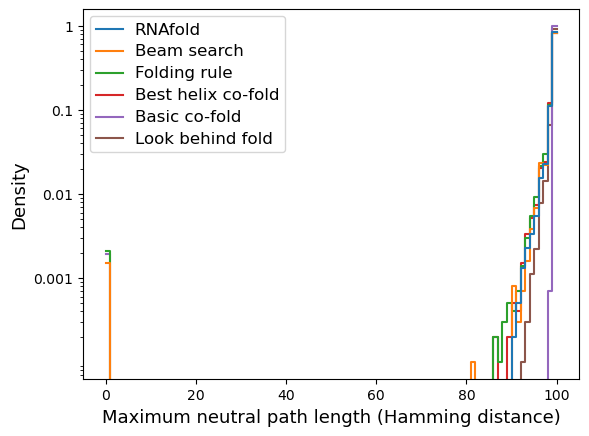

In [183]:
g = sns.histplot(
    data=maxpathDf, x="Hamming", hue="Algorithm", binwidth=1,
    element="step", fill=False,  stat="density", common_norm=False,
    hue_order=Final_toplot[:],
    palette=Final_palette,
    # stat="density", common_norm=False,
)

legend = g.get_legend()
legend.set_title("")
# legend.set_fontsize(20)
for t, l in zip(legend.texts, Final_labels[:]):
    t.set_text(l)
    t.set_fontsize(12)
plt.yscale('log')
plt.yticks([0.001, 0.01, 0.1, 1], [0.001, 0.01, 0.1, 1])
plt.ylabel('Density', fontsize=13)
plt.xlabel('Maximum neutral path length (Hamming distance)', fontsize=13)
plt.savefig('fig/max_with_rnafold.pdf', dpi=200, bbox_inches='tight')